In [1]:
import json                                                                                                                                                                                                                                          
import random
from pathlib import Path
                                                                                                                                                                                                                                                   
import matplotlib.patches as patches
import matplotlib.pyplot as plt                                                                                                                                                                                                                      
import numpy as np
import torch
import torchvision.transforms.functional as TF
from PIL import Image                                                                                                                                                                                                                                
from torch.utils.data import DataLoader, Dataset
from torchmetrics.detection import MeanAveragePrecision                                                                                                                                                                                              
from torchvision.models.detection import (                                                                                                                                                                                                           
    FasterRCNN_ResNet50_FPN_Weights,
    fasterrcnn_resnet50_fpn,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [2]:
# Manual Seed for Reproducibility
STUDENT_ID = 26045171
                                                                                                                                                                                                                                                                                                                                                                                                          
torch.manual_seed(STUDENT_ID)
random.seed(STUDENT_ID)                                                                                                                                                                                                                              
np.random.seed(STUDENT_ID)                                                                                                                                                                                                                           

DATASET_ROOT = Path("26045171/Object_Detection/coco")                                                                                                                                                                                                
RUNS_DIR     = Path("runs/exp3_fasterrcnn")
RUNS_DIR.mkdir(parents=True, exist_ok=True)                                                                                                                                                                                                          
              
# torchvision reserves class index 0 for background, so our 5 lettuce                                                                                                                                                                                
# classes map to indices 1–5, which conveniently matches COCO's 1-indexed IDs.
CLASS_NAMES = ["__background__", "Ready", "empty_pod", "germination", "pod", "young"]                                                                                                                                                                
NUM_CLASSES = len(CLASS_NAMES)  # 6
                                                                                                                                                                                                                                                   
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE} | Classes: {NUM_CLASSES}")

Device: cuda | Classes: 6


In [3]:
class LettuceDataset(Dataset):
    """                                                                                                                                                                                                                                              
    Reads COCO-format annotations and serves (image_tensor, target_dict) pairs.
                                                                                                                                                                                                                                                       
    Faster-RCNN's forward() expects:
     - image:  FloatTensor[3, H, W]  (pixel values in [0, 1])                                                                                                                                                                                       
      - target: dict                                                                                                                                                                                                                                 
          boxes  — FloatTensor[N, 4]  in [x1, y1, x2, y2] (absolute pixel coords)                                                                                                                                                                    
          labels — Int64Tensor[N]     class indices (0 = background, never used here)                                                                                                                                                                
    """                                                                                                                                                                                                                                              
                                                                                                                                                                                                                                                     
    def __init__(self, img_dir, ann_file, augment=False):                                                                                                                                                                                            
        self.img_dir = Path(img_dir)
        self.augment = augment  # only True for the training split                                                                                                                                                                                   
  
        with open(ann_file) as f:                                                                                                                                                                                                                    
            coco = json.load(f)
                                                                                                                                                                                                                                                     
        # Group annotations by image_id for fast lookup                                                                                                                                                                                              
        self.ann_by_img = {}
        for ann in coco["annotations"]:                                                                                                                                                                                                              
            self.ann_by_img.setdefault(ann["image_id"], []).append(ann)
   
        # Only keep images that have at least one annotation —                                                                                                                                                                                       
        # Faster-RCNN's loss computation breaks on empty target boxes
        self.images = [img for img in coco["images"]                                                                                                                                                                                                 
                       if img["id"] in self.ann_by_img]                                                                                                                                                                                              
                                                                                                                                                                                                                                                      
    def __len__(self):                                                                                                                                                                                                                               
        return len(self.images)
   
    def __getitem__(self, idx):
        meta = self.images[idx]
        img  = Image.open(self.img_dir / meta["file_name"]).convert("RGB")                                                                                                                                                                           
  
        # --- Build target tensors ---                                                                                                                                                                                                               
        boxes, labels = [], []
        for ann in self.ann_by_img[meta["id"]]:                                                                                                                                                                                                      
            x, y, w, h = ann["bbox"]
            if w <= 0 or h <= 0:                                                                                                                                                                                                                     
                continue  # skip malformed annotations
            # Convert COCO [x, y, w, h] → [x1, y1, x2, y2]                                                                                                                                                                                           
            boxes.append([x, y, x + w, y + h])                                                                                                                                                                                                       
            # COCO category IDs are 1-indexed and already match our CLASS_NAMES[1:]                                                                                                                                                                  
            labels.append(ann["category_id"])                                                                                                                                                                                                        
                                                                                                                                                                                                                                                      
        target = {                                                                                                                                                                                                                                   
            "boxes":    torch.as_tensor(boxes,  dtype=torch.float32),                                                                                                                                                                                
            "labels":   torch.as_tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([meta["id"]]),                                                                                                                                                                                                  
        }
                                                                                                                                                                                                                                                      
        # --- Transforms ---
        # Convert PIL image to FloatTensor [0,1]. Faster-RCNN applies its own
        # ImageNet normalisation internally, so we don't do it here.                                                                                                                                                                                 
        img = TF.to_tensor(img)                                                                                                                                                                                                                      
                                                                                                                                                                                                                                                      
        if self.augment and random.random() < 0.5:                                                                                                                                                                                                   
            # Random horizontal flip — valid for top-down lettuce images.
            # We mirror the box x-coords to match the flipped image.                                                                                                                                                                                 
            img = TF.hflip(img)                                                                                                                                                                                                                      
            W   = img.shape[-1]                                                                                                                                                                                                                      
            b   = target["boxes"].clone()                                                                                                                                                                                                            
            b[:, [0, 2]] = W - b[:, [2, 0]]                                                                                                                                                                                                          
            target["boxes"] = b                                                                                                                                                                                                                      
   
        return img, target

In [4]:
# Faster-RCNN processes a Python list of images, not a stacked batch tensor,
# because images may have different sizes after the model's internal resizing.                                                                                                                                                                       
# collate_fn keeps them as a tuple of individual tensors instead of stacking.                                                                                                                                                                        
def collate_fn(batch):                                                                                                                                                                                                                               
    return tuple(zip(*batch))                                                                                                                                                                                                                        
                                                                                                                                                                                                                                                   
train_ds = LettuceDataset(DATASET_ROOT / "train", DATASET_ROOT / "train" / "train_annotations.json", augment=True)                                                                                                                                                                                                              
val_ds   = LettuceDataset(DATASET_ROOT / "valid", DATASET_ROOT / "valid" / "valid_annotations.json")                                                                                                                                                                         
test_ds  = LettuceDataset(DATASET_ROOT / "test", DATASET_ROOT / "test"  / "test_annotations.json")
                                                                                                                                                                                                                                                   
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=4, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=2, shuffle=False, num_workers=4, collate_fn=collate_fn, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=2, shuffle=False, num_workers=4, collate_fn=collate_fn, pin_memory=True)
                                                                                                                                                                                                                                                   
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 1050 | Val: 224 | Test: 226


In [5]:
def build_faster_rcnn(num_classes):
    # Load Faster-RCNN with a ResNet-50 + FPN backbone pretrained on COCO.                                                                                                                                                                           
    # The FPN (Feature Pyramid Network) extracts multi-scale features, making it                                                                                                                                                                     
     # robust to the wide range of object sizes in the lettuce images.                                                                                                                                                                                
     weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT                                                                                                                                                                                                
     model   = fasterrcnn_resnet50_fpn(weights=weights)                                                                                                                                                                                               
                                                                                                                                                                                                                                                       
     # The pretrained head predicts 91 COCO classes. We replace only the final                                                                                                                                                                        
     # classification + regression layer with a new one for our 6 classes.                                                                                                                                                                            
     # The backbone weights are kept and will be fine-tuned on our data.                                                                                                                                                                              
     in_features = model.roi_heads.box_predictor.cls_score.in_features                                                                                                                                                                                
     model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)                                                                                                                                                                      
                                                                                                                                                                                                                                                       
     return model

model = build_faster_rcnn(NUM_CLASSES).to(DEVICE)                                                                                                                                                                                                    
  
total     = sum(p.numel() for p in model.parameters())                                                                                                                                                                                               
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")                                                                                                                                                                                                                
print(f"Trainable params: {trainable:,}")

Total params:     41,319,661
Trainable params: 41,097,261


In [6]:
def train_one_epoch(model, loader, optimizer):
    """                                                                                                                                                                                                                                              
    Faster-RCNN returns a loss dict (not predictions) when targets are supplied.
    Four losses are summed:                                                                                                                                                                                                                          
      loss_objectness    — RPN: is there an object in this anchor?
      loss_rpn_box_reg   — RPN: how far is the anchor from a GT box?                                                                                                                                                                                 
      loss_classifier    — ROI head: which class is this proposal?                                                                                                                                                                                   
      loss_box_reg       — ROI head: how far is the proposal from the GT box?                                                                                                                                                                        
    """                                                                                                                                                                                                                                              
    model.train()                                                                                                                                                                                                                                    
    running_loss = 0.0                                                                                                                                                                                                                               
 
    for images, targets in loader:                                                                                                                                                                                                                   
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
                                                                                                                                                                                                                                                     
        loss_dict = model(images, targets)
        loss      = sum(loss_dict.values())                                                                                                                                                                                                          
                                                                                                                                                                                                                                                       
        optimizer.zero_grad()
        loss.backward()                                                                                                                                                                                                                              
        # Clip gradients to prevent exploding gradients, common in two-stage detectors
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)                                                                                                                                                                             
        optimizer.step()
                                                                                                                                                                                                                                                      
        running_loss += loss.item()
    return running_loss / len(loader)

In [7]:
@torch.no_grad()
def evaluate(model, loader):
    """
    Collect predictions and ground truth across the loader, then compute
    mAP using torchmetrics (follows the COCO evaluation protocol).                                                                                                                                                                                   
    model.eval() makes the model return predictions instead of losses.
    """                                                                                                                                                                                                                                              
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox", class_metrics=True)                                                                                                                                                                               
                                                                                                                                                                                                                                                   
    for images, targets in loader:                                                                                                                                                                                                                   
        images = [img.to(DEVICE) for img in images]                                                                                                                                                                                                  
        preds  = model(images)                                                                                                                                                                                                                       
              
        # torchmetrics needs CPU tensors                                                                                                                                                                                                             
        metric.update(
            [{k: v.cpu() for k, v in p.items()} for p in preds],                                                                                                                                                                                     
            [{k: v.cpu() for k, v in t.items()} for t in targets],                                                                                                                                                                                   
        )
                                                                                                                                                                                                                                                   
    return metric.compute()

In [8]:
# SGD with momentum is the standard Faster-RCNN optimizer (matches the paper).
# A lower LR than the paper (0.005 vs 0.02) suits fine-tuning on a small dataset.                                                                                                                                                                    
optimizer = torch.optim.SGD(                                                                                                                                                                                                                         
    model.parameters(), lr=0.005, momentum=0.9, weight_decay=5e-4                                                                                                                                                                                    
)
              
# Cosine annealing smoothly decays LR to near-zero, avoiding sharp drops                                                                                                                                                                             
# that can destabilise fine-tuning on a small dataset.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(                                                                                                                                                                                              
    optimizer, T_max=300, eta_min=1e-5                                                                                                                                                                                                                
)
                                                                                                                                                                                                                                                       
EPOCHS  = 300                                                                                                                                                                                                                                         
PATIENCE = 15
                                                                                                                                                                                                                                                   
best_map50      = 0.0
patience_counter = 0
history = {"train_loss": [], "val_map50": [], "val_map": []}                                                                                                                                                                                         

for epoch in range(1, EPOCHS + 1):                                                                                                                                                                                                                   
    train_loss  = train_one_epoch(model, train_loader, optimizer)
    scheduler.step()                                                                                                                                                                                                                                 
    val_metrics = evaluate(model, val_loader)
                                                                                                                                                                                                                                                   
    map50 = val_metrics["map_50"].item()
    mapx  = val_metrics["map"].item()                                                                                                                                                                                                                
    history["train_loss"].append(train_loss)                                                                                                                                                                                                         
    history["val_map50"].append(map50)
    history["val_map"].append(mapx)                                                                                                                                                                                                                  
              
    print(f"Epoch {epoch:3d}/{EPOCHS}  loss={train_loss:.4f}  "                                                                                                                                                                                      
        f"mAP@50={map50:.4f}  mAP@50-95={mapx:.4f}  "
        f"lr={scheduler.get_last_lr()[0]:.2e}")                                                                                                                                                                                                    
                                                                                                                                                                                                                                                   
    if map50 > best_map50:
        best_map50 = map50                                                                                                                                                                                                                           
        patience_counter = 0
        torch.save(model.state_dict(), RUNS_DIR / "best.pth")
        print(f"  → Best saved (mAP@50={best_map50:.4f})")                                                                                                                                                                                           
    else:                                                                                                                                                                                                                                            
        patience_counter += 1                                                                                                                                                                                                                        
        if patience_counter >= PATIENCE:                                                                                                                                                                                                             
            print(f"Early stopping — no improvement for {PATIENCE} epochs.")
            break

Epoch   1/300  loss=0.7069  mAP@50=0.8883  mAP@50-95=0.5640  lr=5.00e-03
  → Best saved (mAP@50=0.8883)
Epoch   2/300  loss=0.5043  mAP@50=0.9272  mAP@50-95=0.6291  lr=5.00e-03
  → Best saved (mAP@50=0.9272)
Epoch   3/300  loss=0.4475  mAP@50=0.8950  mAP@50-95=0.5889  lr=5.00e-03
Epoch   4/300  loss=0.4161  mAP@50=0.9325  mAP@50-95=0.6232  lr=5.00e-03
  → Best saved (mAP@50=0.9325)
Epoch   5/300  loss=0.3840  mAP@50=0.9220  mAP@50-95=0.6268  lr=5.00e-03
Epoch   6/300  loss=0.3765  mAP@50=0.9364  mAP@50-95=0.6414  lr=5.00e-03
  → Best saved (mAP@50=0.9364)
Epoch   7/300  loss=0.3513  mAP@50=0.9387  mAP@50-95=0.6565  lr=4.99e-03
  → Best saved (mAP@50=0.9387)
Epoch   8/300  loss=0.3396  mAP@50=0.9430  mAP@50-95=0.6535  lr=4.99e-03
  → Best saved (mAP@50=0.9430)
Epoch   9/300  loss=0.3164  mAP@50=0.9109  mAP@50-95=0.6461  lr=4.99e-03
Epoch  10/300  loss=0.3078  mAP@50=0.9321  mAP@50-95=0.6476  lr=4.99e-03
Epoch  11/300  loss=0.2993  mAP@50=0.9423  mAP@50-95=0.6708  lr=4.98e-03
Epoch  12/3

In [10]:
print(test_metrics.keys())

dict_keys(['map', 'map_50', 'map_75', 'map_small', 'map_medium', 'map_large', 'mar_1', 'mar_10', 'mar_100', 'mar_small', 'mar_medium', 'mar_large', 'map_per_class', 'mar_100_per_class', 'classes'])


In [11]:
# Reload the best checkpoint (not the last epoch) to report final numbers
model.load_state_dict(torch.load(RUNS_DIR / "best.pth", map_location=DEVICE))                                                                                                                                                                        
test_metrics = evaluate(model, test_loader)                                                                                                                                                                                                          
                                                                                                                                                                                                                                                   
print("=== TEST SET RESULTS ===")                                                                                                                                                                                                                    
print(f"mAP@50:    {test_metrics['map_50'].item():.4f}")
print(f"mAP@50-95: {test_metrics['map'].item():.4f}")                                                                                                                                                                                                
print(f"Precision: {test_metrics['map_per_class']}")                                                                                                                                                                                                 
print(f"Recall:    {test_metrics['mar_100'].item():.4f}")                                                                                                                                                                                            
                                                                                                                                                                                                                                                   
print("\nPer-class AP@50:")                                                                                                                                                                                                                          
for name, ap in zip(CLASS_NAMES[1:], test_metrics["map_per_class"]):                                                                                                                                                                              
    print(f"  {name:15s}: {ap:.4f}")

=== TEST SET RESULTS ===
mAP@50:    0.9467
mAP@50-95: 0.6540
Precision: tensor([0.4824, 0.7054, 0.6893, 0.7365, 0.6563])
Recall:    0.7374

Per-class AP@50:
  Ready          : 0.4824
  empty_pod      : 0.7054
  germination    : 0.6893
  pod            : 0.7365
  young          : 0.6563


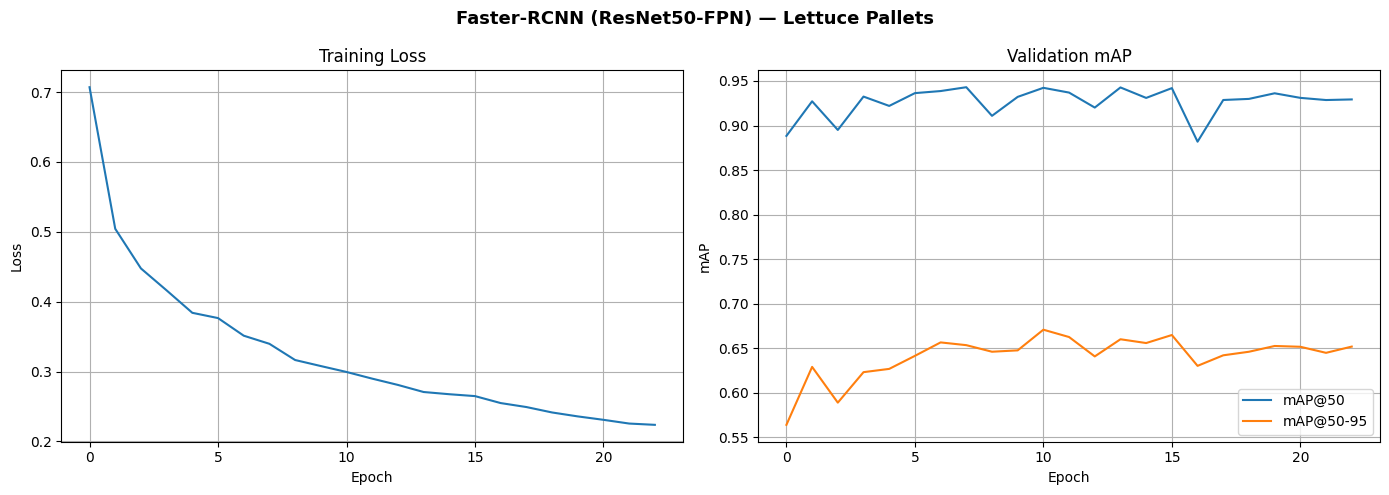

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
                                                                                                                                                                                                                                                       
ax1.plot(history["train_loss"])                                                                                                                                                                                                                      
ax1.set(xlabel="Epoch", ylabel="Loss", title="Training Loss")                                                                                                                                                                                        
ax1.grid(True)                                                                                                                                                                                                                                       
                                                                                                                                                                                                                                                   
ax2.plot(history["val_map50"], label="mAP@50")
ax2.plot(history["val_map"],   label="mAP@50-95")                                                                                                                                                                                                    
ax2.set(xlabel="Epoch", ylabel="mAP", title="Validation mAP")
ax2.legend()                                                                                                                                                                                                                                         
ax2.grid(True)
                                                                                                                                                                                                                                                   
plt.suptitle("Faster-RCNN (ResNet50-FPN) — Lettuce Pallets", fontsize=13, fontweight="bold")                                                                                                                                                         
plt.tight_layout()
plt.savefig(RUNS_DIR / "training_curves.png", dpi=150)                                                                                                                                                                                               
plt.show()

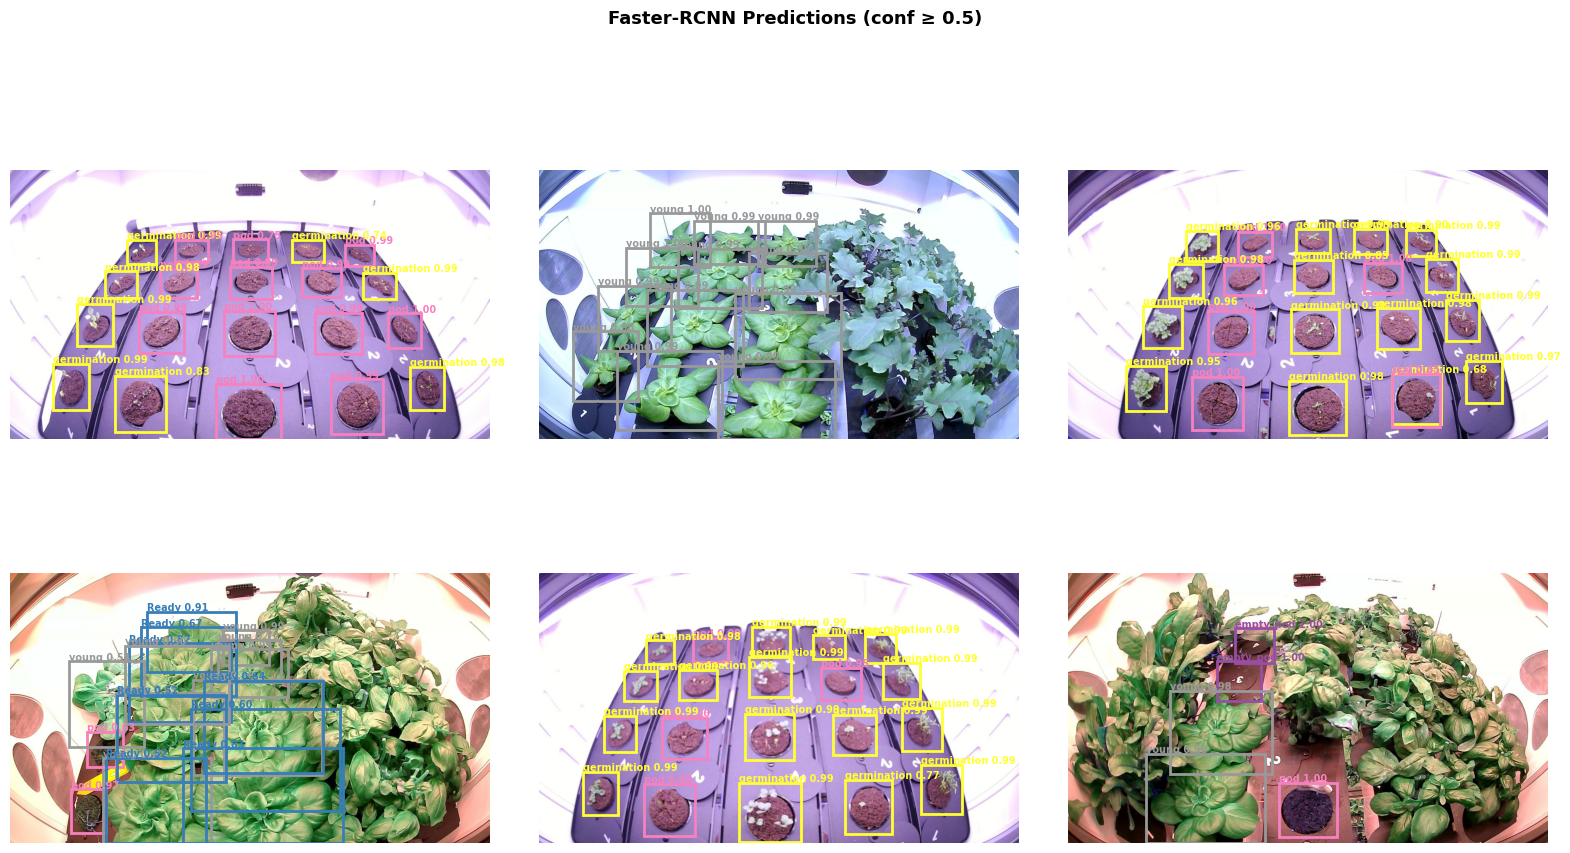

In [13]:
@torch.no_grad()
def plot_predictions(model, dataset, n=6, conf=0.5, seed=STUDENT_ID):                                                                                                                                                                                
    model.eval()                                                                                                                                                                                                                                     
    random.seed(seed)
    indices = random.sample(range(len(dataset)), n)                                                                                                                                                                                                  
    colors  = plt.cm.Set1(np.linspace(0, 1, NUM_CLASSES))                                                                                                                                                                                            
                                                                                                                                                                                                                                                   
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))                                                                                                                                                                                                 
    for ax, idx in zip(axes.flatten(), indices):                                                                                                                                                                                                     
        img_tensor, _ = dataset[idx]                                                                                                                                                                                                                 
        pred = model([img_tensor.to(DEVICE)])[0]
                                                                                                                                                                                                                                                   
        ax.imshow(img_tensor.permute(1, 2, 0).numpy())
        for box, label, score in zip(pred["boxes"], pred["labels"], pred["scores"]):                                                                                                                                                                 
            if score < conf:                                                                                                                                                                                                                         
                continue
            x1, y1, x2, y2 = box.cpu().tolist()                                                                                                                                                                                                      
            cls = label.item()                                                                                                                                                                                                                       
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,                                                                                                                                                                                                          
                linewidth=2, edgecolor=colors[cls], facecolor="none"
            ))                                                                                                                                                                                                                                       
            ax.text(x1, y1 - 4, f"{CLASS_NAMES[cls]} {score:.2f}",
                    color=colors[cls], fontsize=7, fontweight="bold")
        ax.axis("off")

    plt.suptitle(f"Faster-RCNN Predictions (conf ≥ {conf})", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(RUNS_DIR / "predictions.png", dpi=150)
    plt.show()

plot_predictions(model, test_ds)

In [17]:
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
                                                                                                                                                                                                                                                       
# All constants (CLASS_NAMES, NUM_CLASSES, DEVICE, STUDENT_ID) are shared                                                                                                                                                                            
# with Exp 3 — reuse them from the earlier cells.                                                                                                                                                                                                    
                                                                                                                                                                                                                                                   
SSD_RUNS_DIR = Path("runs/exp4_ssd")                                                                                                                                                                                                                 
SSD_RUNS_DIR.mkdir(parents=True, exist_ok=True)                                                                                                                                                                                                      
                                                                                                                                                                                                                                                   
def build_ssd(num_classes):                                                                                                                                                                                                                          
    # SSD300 pretrained on COCO 2017 — same pretraining dataset as Faster-RCNN,
    # making the comparison fair in terms of prior knowledge given to each model.                                                                                                                                                                    
    weights = SSD300_VGG16_Weights.DEFAULT                                                                                                                                                                                                           
    model   = ssd300_vgg16(weights=weights)                                                                                                                                                                                                          
                                                                                                                                                                                                                                                   
    # torchvision's SSD exposes num_classes via the head's classification module.                                                                                                                                                                    
    # We rebuild the head to match our class count (6 = 5 classes + background).                                                                                                                                                                     
    # This is analogous to replacing FastRCNNPredictor in Faster-RCNN.                                                                                                                                                                               
    model.head.classification_head.num_columns = num_classes                                                                                                                                                                                         
                                                                                                                                                                                                                                                   
    # The correct way to replace the SSD head in torchvision:                                                                                                                                                                                        
    from torchvision.models.detection.ssd import SSDClassificationHead                                                                                                                                                                               
    in_channels = [c.in_channels for c in model.head.classification_head.module_list]                                                                                                                                                                
    num_anchors = model.anchor_generator.num_anchors_per_location()                                                                                                                                                                                  
    model.head.classification_head = SSDClassificationHead(                                                                                                                                                                                          
        in_channels, num_anchors, num_classes                                                                                                                                                                                                        
    )                                                                                                                                                                                                                                                
                                                                                                                                                                                                                                                   
    return model

ssd_model = build_ssd(NUM_CLASSES).to(DEVICE)                                                                                                                                                                                                        

total     = sum(p.numel() for p in ssd_model.parameters())                                                                                                                                                                                           
trainable = sum(p.numel() for p in ssd_model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")                                                                                                                                                                                                                
print(f"Trainable params: {trainable:,}")

Total params:     24,280,556
Trainable params: 24,241,836


In [18]:
# Same dataset class and augmentation as Faster-RCNN.
# SSD resizes all images internally to 300×300, so we don't resize here.                                                                                                                                                                             
# Batch=16 is justified by SSD's fixed small input — it's the natural operating                                                                                                                                                                      
# point for this architecture and does not give it an unfair advantage.                                                                                                                                                                              
# Faster-RCNN at batch=2 and SSD at batch=16 are each at their optimal setting.                                                                                                                                                                      
                                                                                                                                                                                                                                                   
ssd_train_ds = LettuceDataset(DATASET_ROOT / "train", DATASET_ROOT / "train" / "train_annotations.json", augment=True)                                                                                                                                                                                                         
ssd_val_ds   = LettuceDataset(DATASET_ROOT / "valid", DATASET_ROOT / "valid" / "valid_annotations.json")                                                                                                                                                                    
ssd_test_ds  = LettuceDataset(DATASET_ROOT / "test", DATASET_ROOT / "test"  / "test_annotations.json")                                                                                                                                                                     
              
ssd_train_loader = DataLoader(ssd_train_ds, batch_size=16, shuffle=True, num_workers=4, collate_fn=collate_fn, pin_memory=True)
ssd_val_loader   = DataLoader(ssd_val_ds,   batch_size=16, shuffle=False, num_workers=4, collate_fn=collate_fn, pin_memory=True)                                                                                                                                                                
ssd_test_loader  = DataLoader(ssd_test_ds,  batch_size=16, shuffle=False, num_workers=4, collate_fn=collate_fn, pin_memory=True)

In [19]:
# Identical optimiser, scheduler, epochs, and early stopping as Faster-RCNN.
# The only difference is the model variable — same training logic applies because                                                                                                                                                                    
# torchvision's SSD and Faster-RCNN share the same forward() API:                                                                                                                                                                                    
# they both return a loss dict during training and predictions during eval.                                                                                                                                                                          
                                                                                                                                                                                                                                                   
ssd_optimizer = torch.optim.SGD(                                                                                                                                                                                                                     
    ssd_model.parameters(), lr=0.005, momentum=0.9, weight_decay=5e-4                                                                                                                                                                                
)                                                                                                                                                                                                                                                    
              
ssd_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(                                                                                                                                                                                          
    ssd_optimizer, T_max=300, eta_min=1e-5
)                                                                                                                                                                                                                                                    
              
EPOCHS  = 300                                                                                                                                                                                                                                        
PATIENCE = 15
                                                                                                                                                                                                                                                   
best_map50       = 0.0
patience_counter = 0
ssd_history = {"train_loss": [], "val_map50": [], "val_map": []}                                                                                                                                                                                     
                                                                                                                                                                                                                                                   
for epoch in range(1, EPOCHS + 1):                                                                                                                                                                                                                   
    train_loss  = train_one_epoch(ssd_model, ssd_train_loader, ssd_optimizer)                                                                                                                                                                        
    ssd_scheduler.step()                                                                                                                                                                                                                             
    val_metrics = evaluate(ssd_model, ssd_val_loader)
                                                                                                                                                                                                                                                   
    map50 = val_metrics["map_50"].item()
    mapx  = val_metrics["map"].item()                                                                                                                                                                                                                
    ssd_history["train_loss"].append(train_loss)                                                                                                                                                                                                     
    ssd_history["val_map50"].append(map50)
    ssd_history["val_map"].append(mapx)                                                                                                                                                                                                              
                                                                                                                                                                                                                                                   
    print(f"Epoch {epoch:3d}/{EPOCHS}  loss={train_loss:.4f}  "                                                                                                                                                                                      
          f"mAP@50={map50:.4f}  mAP@50-95={mapx:.4f}  "                                                                                                                                                                                              
          f"lr={ssd_scheduler.get_last_lr()[0]:.2e}")                                                                                                                                                                                                
              
    if map50 > best_map50:                                                                                                                                                                                                                           
        best_map50 = map50
        patience_counter = 0
        torch.save(ssd_model.state_dict(), SSD_RUNS_DIR / "best.pth")                                                                                                                                                                                
        print(f"  → Best saved (mAP@50={best_map50:.4f})")
    else:                                                                                                                                                                                                                                            
        patience_counter += 1
        if patience_counter >= PATIENCE:                                                                                                                                                                                                             
            print(f"Early stopping — no improvement for {PATIENCE} epochs.")                                                                                                                                                                         
            break

Epoch   1/300  loss=5.5065  mAP@50=0.5112  mAP@50-95=0.2882  lr=5.00e-03
  → Best saved (mAP@50=0.5112)
Epoch   2/300  loss=3.0006  mAP@50=0.7362  mAP@50-95=0.4416  lr=5.00e-03
  → Best saved (mAP@50=0.7362)
Epoch   3/300  loss=2.5052  mAP@50=0.8282  mAP@50-95=0.5125  lr=5.00e-03
  → Best saved (mAP@50=0.8282)
Epoch   4/300  loss=2.2335  mAP@50=0.8764  mAP@50-95=0.5637  lr=5.00e-03
  → Best saved (mAP@50=0.8764)
Epoch   5/300  loss=2.0208  mAP@50=0.8894  mAP@50-95=0.5683  lr=5.00e-03
  → Best saved (mAP@50=0.8894)
Epoch   6/300  loss=1.8663  mAP@50=0.8902  mAP@50-95=0.5750  lr=5.00e-03
  → Best saved (mAP@50=0.8902)
Epoch   7/300  loss=1.7316  mAP@50=0.9148  mAP@50-95=0.5976  lr=4.99e-03
  → Best saved (mAP@50=0.9148)
Epoch   8/300  loss=1.6408  mAP@50=0.9215  mAP@50-95=0.6079  lr=4.99e-03
  → Best saved (mAP@50=0.9215)
Epoch   9/300  loss=1.5720  mAP@50=0.9210  mAP@50-95=0.6156  lr=4.99e-03
Epoch  10/300  loss=1.4740  mAP@50=0.9265  mAP@50-95=0.6235  lr=4.99e-03
  → Best saved (mAP@50

In [20]:
ssd_model.load_state_dict(torch.load(SSD_RUNS_DIR / "best.pth", map_location=DEVICE))
ssd_test_metrics = evaluate(ssd_model, ssd_test_loader)                                                                                                                                                                                              
              
print("=== SSD TEST SET RESULTS ===")                                                                                                                                                                                                                
print(f"mAP@50:    {ssd_test_metrics['map_50'].item():.4f}")
print(f"mAP@50-95: {ssd_test_metrics['map'].item():.4f}")                                                                                                                                                                                            
print(f"Recall:    {ssd_test_metrics['mar_100'].item():.4f}")                                                                                                                                                                                        

print("\nPer-class mAP@50-95:")                                                                                                                                                                                                                      
for name, ap in zip(CLASS_NAMES[1:], ssd_test_metrics["map_per_class"]):
    print(f"  {name:15s}: {ap:.4f}")

=== SSD TEST SET RESULTS ===
mAP@50:    0.9312
mAP@50-95: 0.6387
Recall:    0.7246

Per-class mAP@50-95:
  Ready          : 0.5185
  empty_pod      : 0.6831
  germination    : 0.6747
  pod            : 0.7084
  young          : 0.6087


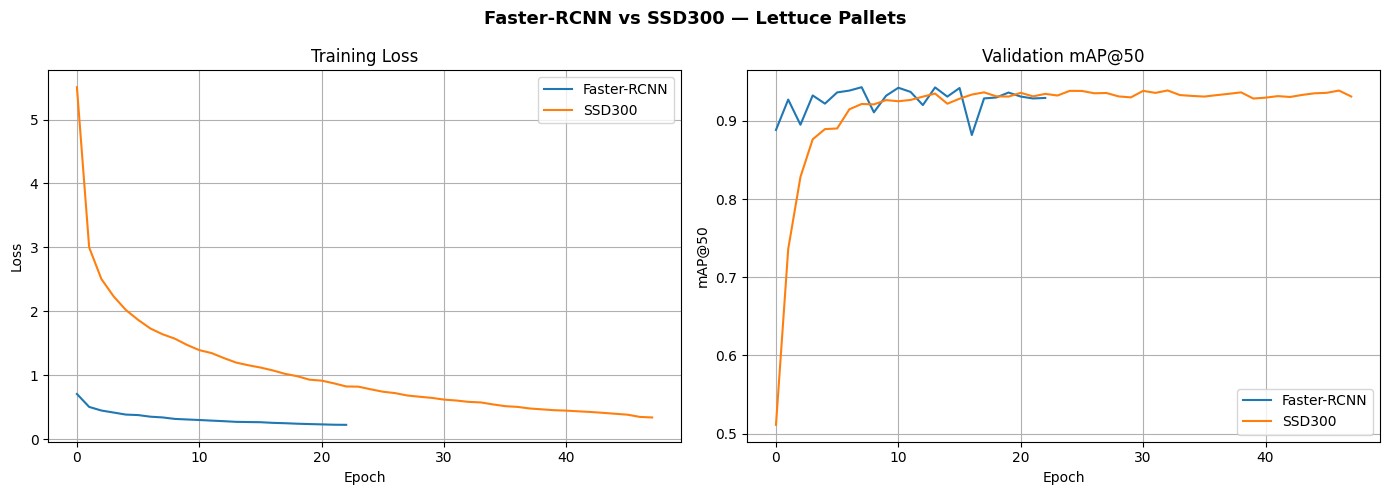

In [23]:
# Load faster-rcnn results from history for direct comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))                                                                                                                                                                                                      
                                                                                                                                                                                                                                                   
# Training loss                                                                                                                                                                                                                                      
axes[0].plot(history["train_loss"], label="Faster-RCNN")                                                                                                                                                                                       
axes[0].plot(ssd_history["train_loss"],   label="SSD300")
axes[0].set(xlabel="Epoch", ylabel="Loss", title="Training Loss")                                                                                                                                                                                    
axes[0].legend()                                                                                                                                                                                                                                     
axes[0].grid(True)                                                                                                                                                                                                                                   
                                                                                                                                                                                                                                                   
# Validation mAP@50
axes[1].plot(history["val_map50"], label="Faster-RCNN")
axes[1].plot(ssd_history["val_map50"],   label="SSD300")                                                                                                                                                                                             
axes[1].set(xlabel="Epoch", ylabel="mAP@50", title="Validation mAP@50")
axes[1].legend()                                                                                                                                                                                                                                     
axes[1].grid(True)
                                                                                                                                                                                                                                                   
plt.suptitle("Faster-RCNN vs SSD300 — Lettuce Pallets", fontsize=13, fontweight="bold")                                                                                                                                                              
plt.tight_layout()
plt.savefig("runs/comparison.png", dpi=150)                                                                                                                                                                                                          
plt.show()

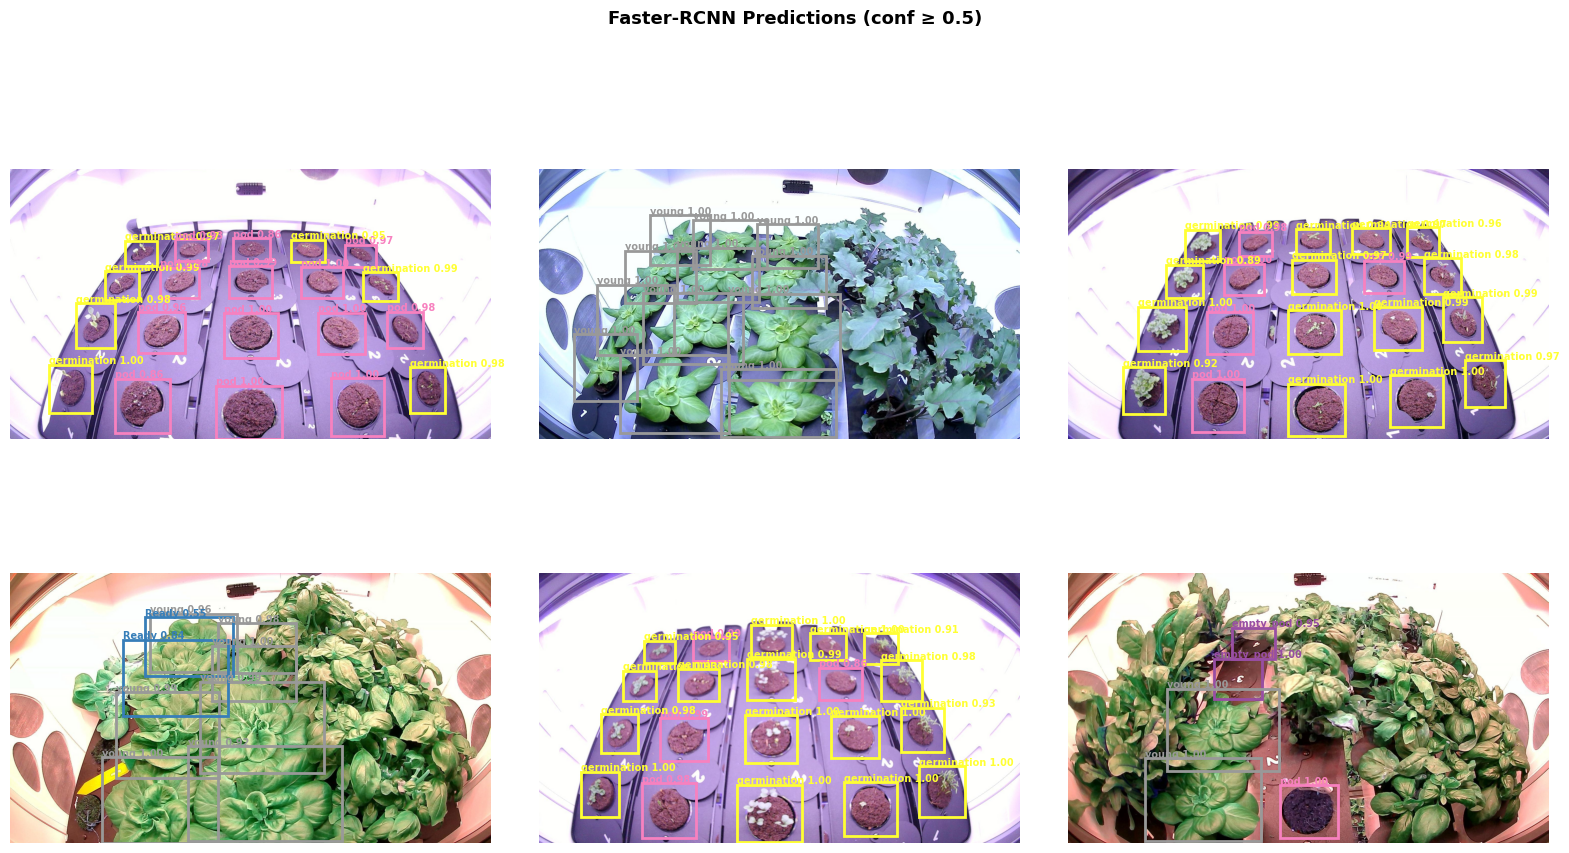

In [24]:
# Identical to Faster-RCNN visualisation — reuses plot_predictions()
plot_predictions(ssd_model, ssd_test_ds)